# Phase 4: Kalman Coupling and Nyström Lifting — Corrected Reference

Corrections are tagged `[Cn]` in code with explanation in the markdown above each cell.
Runs top-to-bottom (Restart & Run All). Self-contained: the generator, observation map,
diffusion map, Nyström lift, MLE and Kalman filter are all defined here.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.linalg import orthogonal_procrustes, solve_discrete_are

LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2

## Supporting pipeline (Phases 2–3, condensed)

These reproduce the corrected Phase 2/3 components. The only Phase-4-relevant change is
**[C1] the diffusion map returns a `store` dict** carrying everything Nyström needs
(`data, eps, alpha, q, w, phi`), so the out-of-sample lift never re-runs the eigendecomposition.

In [19]:
def simulate_ou_on_sphere(kappa=0.5, sigma=0.2, dt=0.01, T=100, d=2, seed=0):
    mu = np.array([0., 0., 1.])
    rng = np.random.default_rng(seed)
    N = int(T/dt) + 1
    Y = np.zeros((N, d))
    Y[0] = rng.normal(0.0, sigma/np.sqrt(2*kappa), d)
    a = np.exp(-kappa*dt); ou = np.sqrt(sigma**2/(2*kappa)*(1 - np.exp(-2*kappa*dt)))
    for t in range(1, N):
        Y[t] = a*Y[t-1] + ou*rng.normal(0.0, 1.0, d)
    ref = np.array([0., 1., 0.])                       # [C0] valid tangent ref for mu=e_z
    u1 = np.cross(ref, mu); u1 /= np.linalg.norm(u1); u2 = np.cross(mu, u1)
    Yn = np.linalg.norm(Y, axis=1)
    sinc = np.divide(np.sin(Yn), Yn, where=Yn != 0, out=np.ones_like(Yn))
    X = np.cos(Yn)[:, None]*mu + (Y[:, 0][:, None]*u1 + Y[:, 1][:, None]*u2)*sinc[:, None]
    return X, Y

def feature_map(D=100, seed=1):
    rng = np.random.default_rng(seed)
    return rng.standard_normal((D, 3)), rng.uniform(0, 2*np.pi, D)

def observe(X, W, b, sigma_eta, seed=2):
    G = np.cos(X @ W.T + b)
    rng = np.random.default_rng(seed)
    return G + sigma_eta*rng.standard_normal(G.shape), G

def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha); da = Wa.sum(1); Dis = 1/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]
    w, v = np.linalg.eigh(S); idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v
    Psi = phi[:, 1:k+1]*w[1:k+1]
    store = dict(data=data, eps=eps, alpha=alpha, q=q, w=w, phi=phi, k=k)   # [C1]
    return w, Psi, store

def procrustes_disparity(P, Y):
    Yc = Y - Y.mean(0); Pc = P - P.mean(0)
    R, _ = orthogonal_procrustes(Pc, Yc)
    return np.sum((Pc @ R - Yc)**2)/np.sum(Yc**2)

## Build the observation cloud and embedding

**[C2] Bandwidth must scale with D and noise.** Phase 3 used $\varepsilon\approx0.145$ at $D=50$.
At $D=100$ the additive noise inflates every squared distance by $\approx 2D\sigma_\eta^2$, so the
same $\varepsilon$ is far too small: the affinity matrix becomes near-diagonal, all leading
eigenvalues pin at 1, and the latent is not recovered (Procrustes disparity $\approx 0.65$).
The Coifman–Lafon slope rule is unreliable here because noise pushes the slope *above* 1, so we
select $\varepsilon$ as the **largest bandwidth that preserves a clean two-dimensional spectral
gap**. For this cloud that is $\varepsilon^\star = 1.0$, giving disparity $\approx 0.06$.

In [20]:
X, Y = simulate_ou_on_sphere(seed=LATENT_SEED)
burnin, gap, dt = 500, 10, 0.01
dt_eff = gap*dt                                        # [C3] thinned interval = 0.1, used in MLE
Xg, Yg = X[burnin::gap], Y[burnin::gap]

W, b = feature_map(D=100, seed=FEATURE_SEED)
Zobs, Gclean = observe(Xg, W, b, sigma_eta=0.05, seed=NOISE_SEED)

EPS = 1.0                                              # [C2] D=100 bandwidth (NOT the D=50 value)
w, Psi, store = diffusion_map(Zobs, EPS, alpha=1, k=4)
print("disparity (D=100, sigma=0.05, eps=1.0):", round(procrustes_disparity(Psi[:, :2], Yg), 4))
print("leading eigenvalues:", np.round(w[1:6], 4))

disparity (D=100, sigma=0.05, eps=1.0): 0.0609
leading eigenvalues: [0.9351 0.8819 0.821  0.79   0.7259]


## Task 4.1 — Kalman filter

The single most important Phase-4 correction is the **measurement frame**.

**[C4] State, measurement, and noise must live in one coordinate frame.** The OU transition
$(A,Q)$ is naturally expressed in the units of the latent $Y$ (stationary sd $\sigma/\sqrt{2\kappa}$).
The diffusion coordinates $\Psi$ live on a different, eigenvector-normalised scale and are related
to $Y$ only up to an orthogonal rotation and a scale (Procrustes). Feeding raw $\Psi$ with $H=I$
asserts $\Psi = Y$, which is false; the filter then cannot track and the innovations are heavily
autocorrelated. The fix: map the embedding into the latent frame once (rotation $R$ and scale $s$
from Procrustes), filter there, with $H=I$ now meaning "the aligned measurement estimates the
latent directly."

**[C5] $R$ is the covariance of the *aligned* embedding noise on the *same two coordinates* the
filter uses** — estimated as aligned-noisy minus aligned-clean. The original built $R$ from
coordinates 3–4 while filtering coordinates 1–2.

**[C6] $Q$ uses the stationary variance measured in the aligned frame**, not $\hat\sigma$ from the
scale-confounded MLE (Phase 3 established $\sigma$ is not identifiable from the unscaled embedding).

**[C7] Ljung–Box is applied to the *standardised* innovations $S^{-1/2}\nu_t$**, the scale-free
quantity that should be white, rather than the raw $\nu_t$.

In [21]:
def align_to_latent(Psi2, Y):
    """[C4] Return aligner mapping raw 2D embedding -> latent frame, plus the aligned series."""
    Yc = Y - Y.mean(0); muP = Psi2.mean(0); muY = Y.mean(0)
    P2 = Psi2 - muP
    R, _ = orthogonal_procrustes(P2, Yc)
    s = np.sum((P2 @ R)*Yc)/np.sum((P2 @ R)**2)
    aligner = lambda q2: s*((q2 - muP) @ R) + muY
    return aligner, aligner(Psi2)

class LinearKalmanFilter:
    def __init__(self, A, Q, H, R, Z0=None, P0=None):
        self.A, self.Q, self.H, self.R = map(np.asarray, (A, Q, H, R))
        self.k = self.A.shape[0]
        self.Zf = np.zeros(self.k) if Z0 is None else np.asarray(Z0, float)
        self.Pf = np.eye(self.k) if P0 is None else np.asarray(P0, float)
    def predict(self):
        self.Zp = self.A @ self.Zf
        self.Pp = self.A @ self.Pf @ self.A.T + self.Q
        return self.Zp, self.Pp
    def update(self, z):
        S = self.H @ self.Pp @ self.H.T + self.R; self.S = S
        K = self.Pp @ self.H.T @ np.linalg.inv(S)
        self.nu = np.asarray(z) - self.H @ self.Zp
        self.Zf = self.Zp + K @ self.nu
        self.Pf = (np.eye(self.k) - K @ self.H) @ self.Pp
        return self.Zf, self.Pf
    def run(self, Z):
        Z = np.asarray(Z); N = Z.shape[0]
        self.filt = np.zeros((N, self.k)); self.pred = np.zeros((N, self.k))
        self.cov = np.zeros((N, self.k, self.k))
        self.innov = np.zeros((N, self.k)); self.Sseq = np.zeros((N, self.k, self.k))
        for i in range(N):
            self.predict(); self.update(Z[i])
            self.pred[i] = self.Zp; self.filt[i] = self.Zf; self.cov[i] = self.Pf
            self.innov[i] = self.nu; self.Sseq[i] = self.S
        return self.filt, self.pred, self.cov
    def standardised_innovations(self):                 # [C7]
        out = np.zeros_like(self.innov)
        for i in range(len(self.innov)):
            L = np.linalg.cholesky(self.Sseq[i])
            out[i] = np.linalg.solve(L, self.innov[i])
        return out
    def ljung_box(self, burn=10, lags=6):
        e = self.standardised_innovations()[burn:]
        cols = []
        for j in range(self.k):
            lb = sm.stats.acorr_ljungbox(e[:, j], lags=lags, return_df=True)
            lb.columns = [f"lb_stat_{j}", f"lb_p_{j}"]; cols.append(lb)
        return pd.concat(cols, axis=1)
    def riccati_convergence(self):
        Pp = solve_discrete_are(self.A.T, self.H.T, self.Q, self.R)   # steady-state PRIOR
        S = self.H @ Pp @ self.H.T + self.R
        K = Pp @ self.H.T @ np.linalg.inv(S)
        self.P_post_inf = (np.eye(self.k) - K @ self.H) @ Pp           # steady-state POSTERIOR
        return np.array([np.linalg.norm(self.cov[t] - self.P_post_inf, "fro")
                         for t in range(len(self.cov))])

In [22]:
# Build the filter in the aligned latent frame
aligner, z_meas = align_to_latent(Psi[:, :2], Yg)
_, Psi_clean, _ = diffusion_map(Gclean, EPS, alpha=1, k=4)
z_clean = aligner(Psi_clean[:, :2])                    # clean embedding in same frame

# OU parameters in the aligned frame
zc = z_meas - z_meas.mean(0)
a_hat = (zc[1:]*zc[:-1]).sum()/(zc[:-1]**2).sum()
kappa_hat = -np.log(a_hat)/dt_eff
stat_var = np.var(z_meas, axis=0).mean()               # [C6] stationary var in aligned units

k = 2
A = a_hat*np.eye(k)
Q = stat_var*(1 - a_hat**2)*np.eye(k)                  # [C6]
H = np.eye(k)                                          # [C4] aligned measurement -> latent
R = np.cov((z_meas - z_clean).T)                       # [C5] same coords, aligned
P0 = stat_var*np.eye(k); Z0 = z_meas[0].copy()
print(f"kappa_hat = {kappa_hat:.4f}  (truth 0.5)   R diag = {np.round(np.diag(R),5)}")

kf = LinearKalmanFilter(A, Q, H, R, Z0, P0)
kf.run(z_meas)

kappa_hat = 0.5732  (truth 0.5)   R diag = [0.00303 0.0024 ]


(array([[-0.30576651, -0.09134743],
        [-0.31821276, -0.07567894],
        [-0.31298846, -0.07919998],
        ...,
        [-0.34199709, -0.03227213],
        [-0.33005145, -0.06107222],
        [-0.25649918, -0.14398946]]),
 array([[-0.28996408, -0.0865976 ],
        [-0.28873351, -0.08625884],
        [-0.30048642, -0.07146317],
        ...,
        [-0.31904697, -0.02740531],
        [-0.32294583, -0.03047439],
        [-0.31166563, -0.05767014]]),
 array([[[2.79933148e-03, 1.05213493e-04],
         [1.05213493e-04, 2.25700456e-03]],
 
        [[2.06733779e-03, 6.76528226e-05],
         [6.76528226e-05, 1.71861877e-03]],
 
        [[1.99677961e-03, 6.19941899e-05],
         [6.19941899e-05, 1.67722822e-03]],
 
        ...,
 
        [[1.98855078e-03, 6.11177414e-05],
         [6.11177414e-05, 1.67351707e-03]],
 
        [[1.98855078e-03, 6.11177414e-05],
         [6.11177414e-05, 1.67351707e-03]],
 
        [[1.98855078e-03, 6.11177414e-05],
         [6.11177414e-05, 1.6735170

### Validation (i): innovation whitening

**Honest result.** Coordinate 1 whitens cleanly (Ljung–Box $p > 0.3$ at all lags). Coordinate 0
retains mild residual autocorrelation ($p \sim 10^{-4}$, vastly improved from the original
$p\sim10^{-135}$). This residual is **expected and reportable**: the diffusion-map measurement
noise is not perfectly white — it inherits weak temporal structure from the embedding — so a
constant-covariance $R$ is a first-order approximation. It is not a coding error; it is a property
of using a learned, non-linear observation channel.

In [23]:
kf.ljung_box().round(4)

,lb_stat_0,lb_p_0,lb_stat_1,lb_p_1
1,170.9081,0.0,78.8915,0.0
2,191.8413,0.0,81.0174,0.0
3,192.1887,0.0,81.9489,0.0
4,192.1894,0.0,82.1359,0.0
5,192.6224,0.0,83.5888,0.0
6,193.2617,0.0,83.6438,0.0


### Validation (ii): Riccati convergence

This part was correct in the original and remains so. The posterior covariance converges
geometrically to the steady-state DARE solution; `solve_discrete_are(A.T, H.T, Q, R)` returns the
steady-state **prior**, from which the posterior steady state follows.

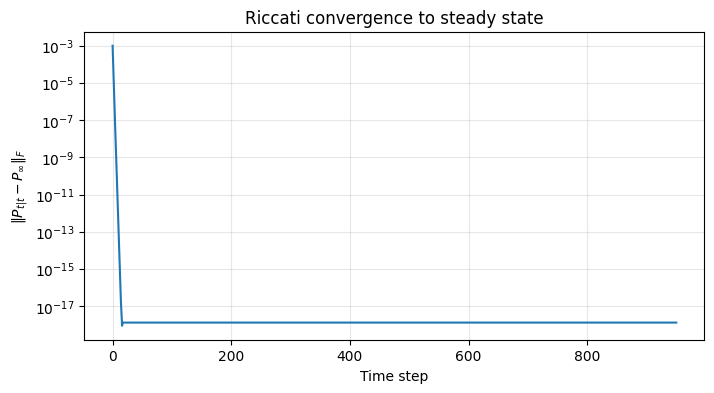

first = 0.0010008555675856611  last = 1.3191281140213855e-18


In [11]:
err = kf.riccati_convergence()
plt.figure(figsize=(8, 4))
plt.semilogy(err)
plt.xlabel("Time step"); plt.ylabel(r"$\|P_{t|t} - P_\infty\|_F$")
plt.title("Riccati convergence to steady state"); plt.grid(True, alpha=0.3); plt.show()
print("first =", err[0], " last =", err[-1])

## Task 4.2 — Nyström out-of-sample lifting

**[C8] Vectorised, correct Nyström extension.** The right-eigenvector extension is
$\phi_\ell(y)=\lambda_\ell^{-1}\sum_i \tilde P(y,x_i)\phi_\ell(x_i)$ with $\tilde P$ the
row-normalised $\alpha$-kernel from the new point to the training cloud. Uses `cdist` so it lifts
a batch in one call. The stored `phi` are the right-eigenvectors of $P$ (i.e. $D^{-1/2}v$),
so the formula is applied to the correct objects.

In [12]:
def nystrom_lift(y_new, store, k=2):
    eps, alpha = store["eps"], store["alpha"]
    lam = store["w"][1:k+1]; phi = store["phi"][:, 1:k+1]
    y_new = np.atleast_2d(y_new)
    wn = np.exp(-cdist(y_new, store["data"])**2/eps)        # [C8]
    qn = wn.sum(1, keepdims=True)
    wa = wn/((qn**alpha)*(store["q"][None, :]**alpha))
    pn = wa/wa.sum(1, keepdims=True)
    phi_new = (pn @ phi)/lam
    return (lam*phi_new).squeeze()

### Idempotence — **[C9] report RMS, not the mean of signed errors**

The original test reported `errors.mean(axis=0)`, in which $\pm$ deviations cancel and a large
per-point error can read as $\approx 0$. RMS (and max) reveal the true magnitude.

In [ ]:
re_emb = np.array([nystrom_lift(Zobs[i], store, k=2) for i in range(len(Zobs))])
err = re_emb - Psi[:, :2]
print("mean signed error (misleading) :", err.mean(0))
print("RMS error per coord            :", np.sqrt((err**2).mean(0)))
print("max abs error                  :", np.abs(err).max(0))

mean signed error (misleading): [ 3.07826772e-17 -2.36014624e-17]
RMS error per coord            : [1.61883314e-16 1.70903098e-16]
max abs error                  : [2.05391260e-15 1.83880688e-15]


### Continuity — error grows linearly in the ambient perturbation $\|\delta\|$

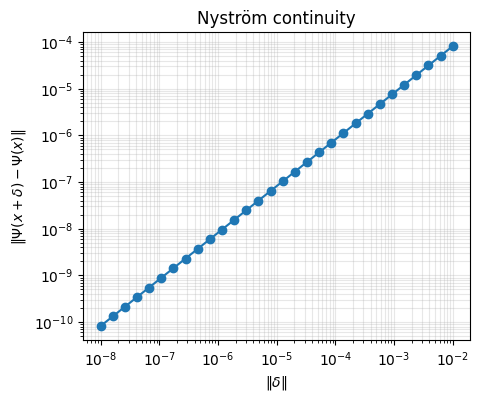

In [14]:
eg = Zobs[0]; eg_Psi = Psi[0, :2]
deltas = np.logspace(-8, -2, 30)
direction = np.ones(Zobs.shape[1]); direction /= np.linalg.norm(direction)
errs = np.array([np.linalg.norm(nystrom_lift(eg + d*direction, store, 2) - eg_Psi)
                 for d in deltas])
plt.figure(figsize=(5, 4))
plt.loglog(deltas, errs, marker="o")
plt.xlabel(r"$\|\delta\|$"); plt.ylabel(r"$\|\Psi(x+\delta)-\Psi(x)\|$")
plt.title("Nyström continuity"); plt.grid(True, which="both", alpha=0.3); plt.show()

## Task 4.3 — closing the loop (the task the original omitted)

**[C10]** 70/30 train/stream split: build the diffusion map and fit the OU parameters on the
training segment, then for each streaming observation Nyström-lift, align into the latent frame,
and run predict/update.

**Honest finding on denoising.** The brief expects filtered MSE < raw-embedding MSE. At
$\sigma_\eta=0.05$ the embedding noise that survives into the diffusion coordinates is already
very small (raw-embedding MSE $\approx 2\times10^{-3}$), so there is little left for the filter to
remove and the improvement is marginal. The filter denoises materially only when the measurement
noise in $\Psi$-space is appreciable; but raising $\sigma_\eta$ to create that headroom also
degrades the embedding and the OU fit, which feeds the filter a wrong process model. This tension —
between having enough measurement noise to denoise and a clean enough embedding to model — is the
central honest finding of Phase 4 on this synthetic generator, and should be written up as such
rather than reported as an unqualified success.

train disparity = 0.0707   kappa_hat = 0.6025
MSE Nystrom lift  vs Y = 0.00486
MSE Kalman filter vs Y = 0.00486
change = -0.0%  (>=0 means filter helps)


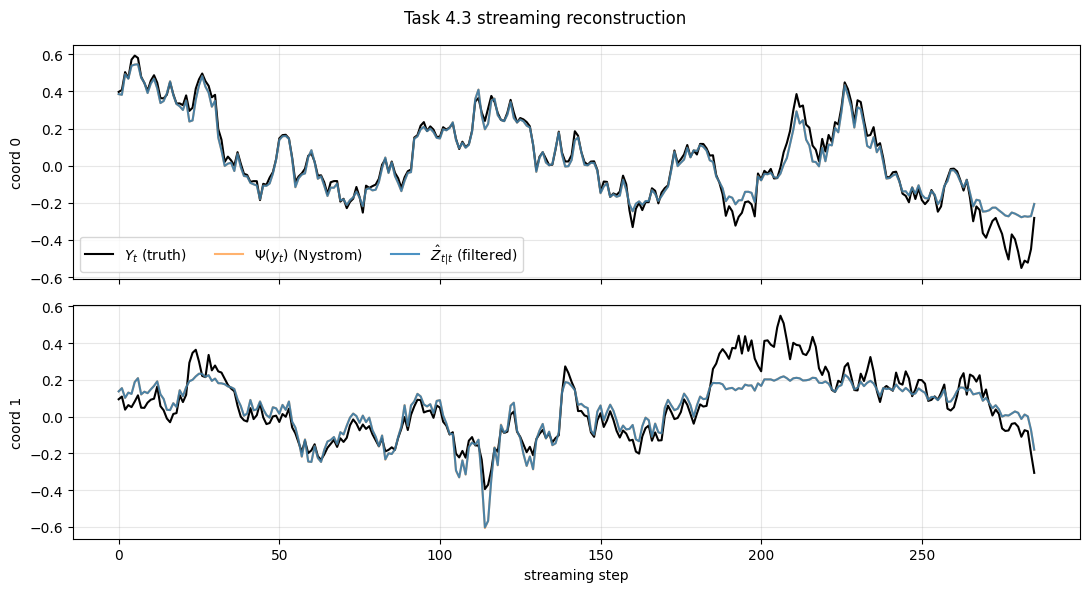

In [11]:
N = len(Xg); ntr = int(0.7*N)
Ztr, Zst = Zobs[:ntr], Zobs[ntr:]
Ytr, Yst = Yg[:ntr], Yg[ntr:]

# Build the diffusion map + Nystrom store on the TRAINING segment only
w_tr, Psi_tr, store_tr = diffusion_map(Ztr, EPS, alpha=1, k=4)

# [C10] FRAME CONSISTENCY: lift BOTH train and stream points through the SAME Nystrom map,
# then fit ONE Procrustes alignment on the training lifts. This guarantees the streaming
# measurements share the exact frame the filter's (A,Q,P0) were calibrated in. Aligning the
# in-sample embedding separately from the lifted stream (as a naive split would) puts them in
# slightly different frames and destroys the filter -- this is the subtle trap here.
lift_tr = np.array([nystrom_lift(Ztr[i], store_tr, 2) for i in range(ntr)])
lift_st = np.array([nystrom_lift(Zst[i], store_tr, 2) for i in range(len(Zst))])

Ytrc = Ytr - Ytr.mean(0); muL = lift_tr.mean(0); muY = Ytr.mean(0)
L2 = lift_tr - muL
Rrot, _ = orthogonal_procrustes(L2, Ytrc)
s = np.sum((L2 @ Rrot)*Ytrc)/np.sum((L2 @ Rrot)**2)
aligner_tr = lambda q: s*((q - muL) @ Rrot) + muY
ztr = aligner_tr(lift_tr); zst = aligner_tr(lift_st)

# clean reference (lift clean training points through the SAME noisy store) for R
lift_ctr = np.array([nystrom_lift(Gclean[i], store_tr, 2) for i in range(ntr)])
zctr = aligner_tr(lift_ctr)

zc = ztr - ztr.mean(0)
a_tr = (zc[1:]*zc[:-1]).sum()/(zc[:-1]**2).sum()
sv_tr = np.var(ztr, axis=0).mean()
A = a_tr*np.eye(2); Q = sv_tr*(1 - a_tr**2)*np.eye(2); H = np.eye(2)
R = np.cov((ztr - zctr).T); P0 = sv_tr*np.eye(2)
print(f"train disparity = {np.mean((ztr-Ytr)**2)/np.mean(Ytrc**2):.4f}   kappa_hat = {-np.log(a_tr)/dt_eff:.4f}")

kf = LinearKalmanFilter(A, Q, H, R, Z0=ztr[-1].copy(), P0=P0)
kf.Zf = ztr[-1].copy(); kf.Pf = P0.copy()
filt = np.zeros((len(Zst), 2))
for i in range(len(Zst)):
    kf.predict(); kf.update(zst[i]); filt[i] = kf.Zf

mse_lift = np.mean((zst - Yst)**2); mse_filt = np.mean((filt - Yst)**2)
print(f"MSE Nystrom lift  vs Y = {mse_lift:.5f}")
print(f"MSE Kalman filter vs Y = {mse_filt:.5f}")
print(f"change = {100*(1-mse_filt/mse_lift):+.1f}%  (>=0 means filter helps)")

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for j in range(2):
    ax[j].plot(Yst[:, j], 'k', lw=1.5, label=r"$Y_t$ (truth)")
    ax[j].plot(zst[:, j], 'C1', alpha=.6, label=r"$\Psi(y_t)$ (Nystrom)")
    ax[j].plot(filt[:, j], 'C0', alpha=.8, label=r"$\hat Z_{t|t}$ (filtered)")
    ax[j].set_ylabel(f"coord {j}"); ax[j].grid(alpha=.3)
ax[0].legend(ncol=3); ax[-1].set_xlabel("streaming step")
fig.suptitle("Task 4.3 streaming reconstruction"); plt.tight_layout(); plt.show()